In [1]:
# Khai báo thư viện ảnh
import cv2
import matplotlib.pyplot as plt

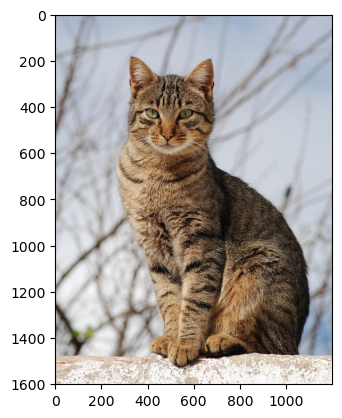

In [2]:
# Kiểm tra opencv đọc ảnh và đặt ảnh cho đúng hiển thị ban đầu
img = cv2.imread('cat.jpg')
img = img[:,:,::-1]
plt.imshow(img)

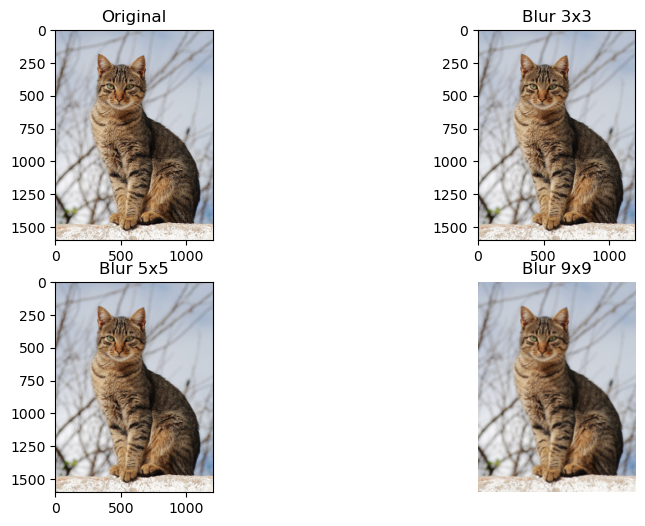

In [7]:
#1. Box Filter (cv2.blur / cv2.boxFilter)
blur_3 = cv2.blur(img, (3,3))
blur_5 = cv2.blur(img, (5,5))
blur_9 = cv2.blur(img, (9,9))

plt.figure(figsize=(10,6))
plt.subplot(221), plt.imshow(img), plt.title('Original')
plt.subplot(222), plt.imshow(blur_3), plt.title('Blur 3x3')
plt.subplot(223), plt.imshow(blur_5), plt.title('Blur 5x5')
plt.subplot(224), plt.imshow(blur_9), plt.title('Blur 9x9')
plt.axis('off')
plt.show()

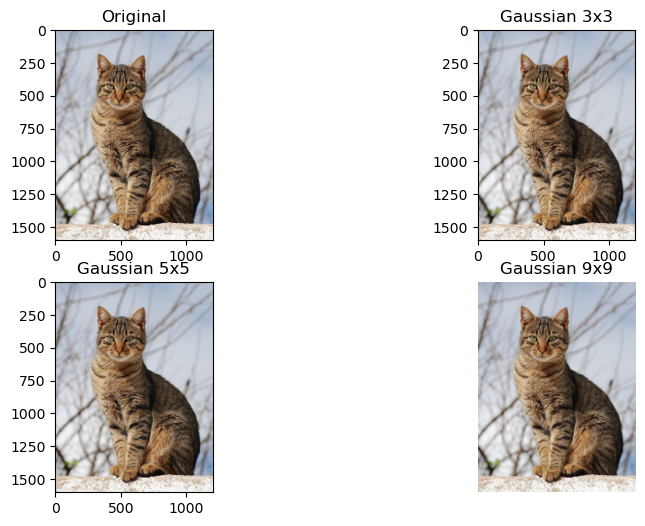

In [8]:
#2. Gaussian Filter (kích thước kernel là số lẻ)
gauss_3 = cv2.GaussianBlur(img, (3,3), 0)
gauss_5 = cv2.GaussianBlur(img, (5,5), 0)
gauss_9 = cv2.GaussianBlur(img, (9,9), 0)

plt.figure(figsize=(10,6))
plt.subplot(221), plt.imshow(img), plt.title('Original')
plt.subplot(222), plt.imshow(gauss_3), plt.title('Gaussian 3x3')
plt.subplot(223), plt.imshow(gauss_5), plt.title('Gaussian 5x5')
plt.subplot(224), plt.imshow(gauss_9), plt.title('Gaussian 9x9')
plt.axis('off')
plt.show()

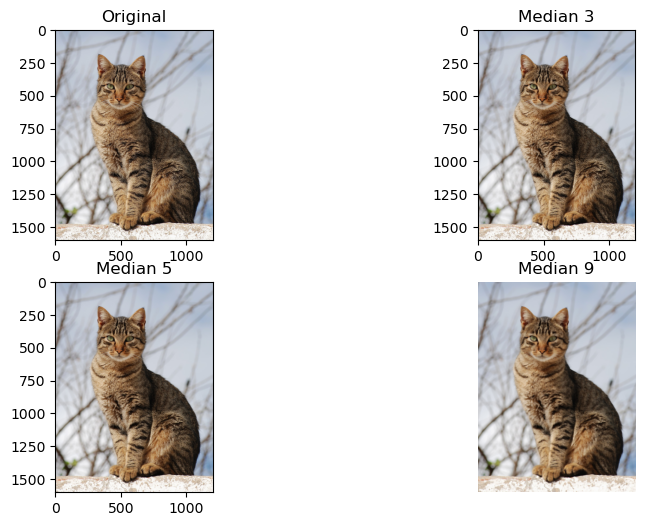

In [9]:
#3. Median Filter
median_3 = cv2.medianBlur(img, 3)
median_5 = cv2.medianBlur(img, 5)
median_9 = cv2.medianBlur(img, 9)

plt.figure(figsize=(10,6))
plt.subplot(221), plt.imshow(img), plt.title('Original')
plt.subplot(222), plt.imshow(median_3), plt.title('Median 3')
plt.subplot(223), plt.imshow(median_5), plt.title('Median 5')
plt.subplot(224), plt.imshow(median_9), plt.title('Median 9')
plt.axis('off')
plt.show()

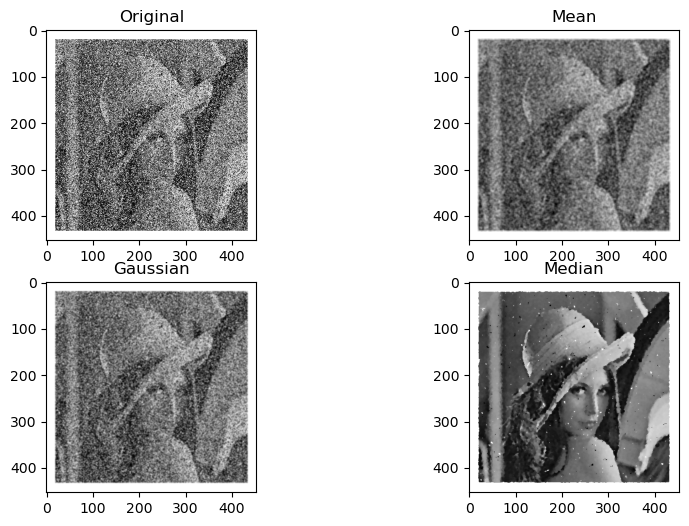

In [10]:
#4. Kiểm tra với ảnh pepper noise
img_p1 = cv2.imread('pepper_noise01.png', 0)
img_p2 = cv2.imread('pepper_noise02.png', 0)

mean = cv2.blur(img_p1, (5,5))
gauss = cv2.GaussianBlur(img_p1, (5,5), 0)
median = cv2.medianBlur(img_p1, 5)

plt.figure(figsize=(10,6))
plt.subplot(221), plt.imshow(img_p1, cmap='gray'), plt.title('Original')
plt.subplot(222), plt.imshow(mean, cmap='gray'), plt.title('Mean')
plt.subplot(223), plt.imshow(gauss, cmap='gray'), plt.title('Gaussian')
plt.subplot(224), plt.imshow(median, cmap='gray'), plt.title('Median')
plt.show()

5. Nhận xét kích thước filter

Kernel nhỏ => giữ chi tiết

Kernel lớn => mờ mạnh, mất biên

Chọn kernel phụ thuộc loại nhiễu

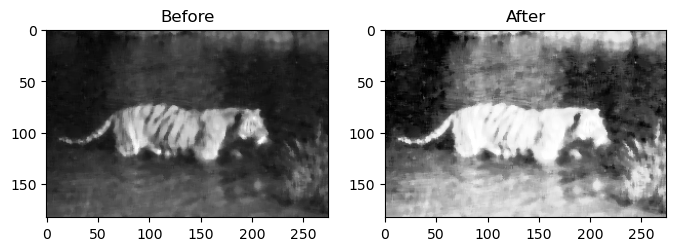

In [11]:
# 6. Cân bằng sáng – Equalize Histogram
img = cv2.imread('pepper_noise02.png')

blur = cv2.medianBlur(img, 5)
gray = cv2.cvtColor(blur, cv2.COLOR_BGR2GRAY)

equal = cv2.equalizeHist(gray)

plt.figure(figsize=(8,4))
plt.subplot(121), plt.imshow(gray, cmap='gray'), plt.title('Before')
plt.subplot(122), plt.imshow(equal, cmap='gray'), plt.title('After')
plt.show()

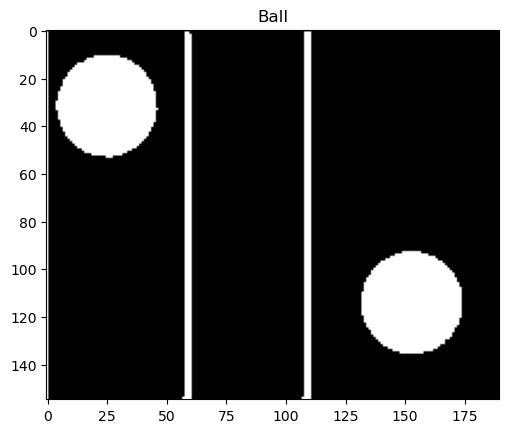

In [14]:
#7. FILTER bằng phép toán số học & logic
#a. Crop 2 ảnh về 190×155
img1 = cv2.imread('exT3_01.jpg')
img2 = cv2.imread('exT3_02.jpg')

img1 = img1[:155, 1:191]
img2 = img2[:155, :190]

#b. Chuyển sang ảnh âm bản (Negative)
inv_img1 = cv2.bitwise_not(img1)
inv_img2 = cv2.bitwise_not(img2)

#c. Lấy ảnh chỉ còn quả bóng
ball = cv2.absdiff(inv_img1, inv_img2)

gray = cv2.cvtColor(ball, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 40, 255, cv2.THRESH_BINARY)

plt.imshow(thresh, cmap='gray')
plt.title('Ball')
plt.show()

#Nếu còn vạch trắng => khắc phục:

# Threshold
# Morphology Opening / Closing

#kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
#clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

# Một số bài tập mở rộng: 

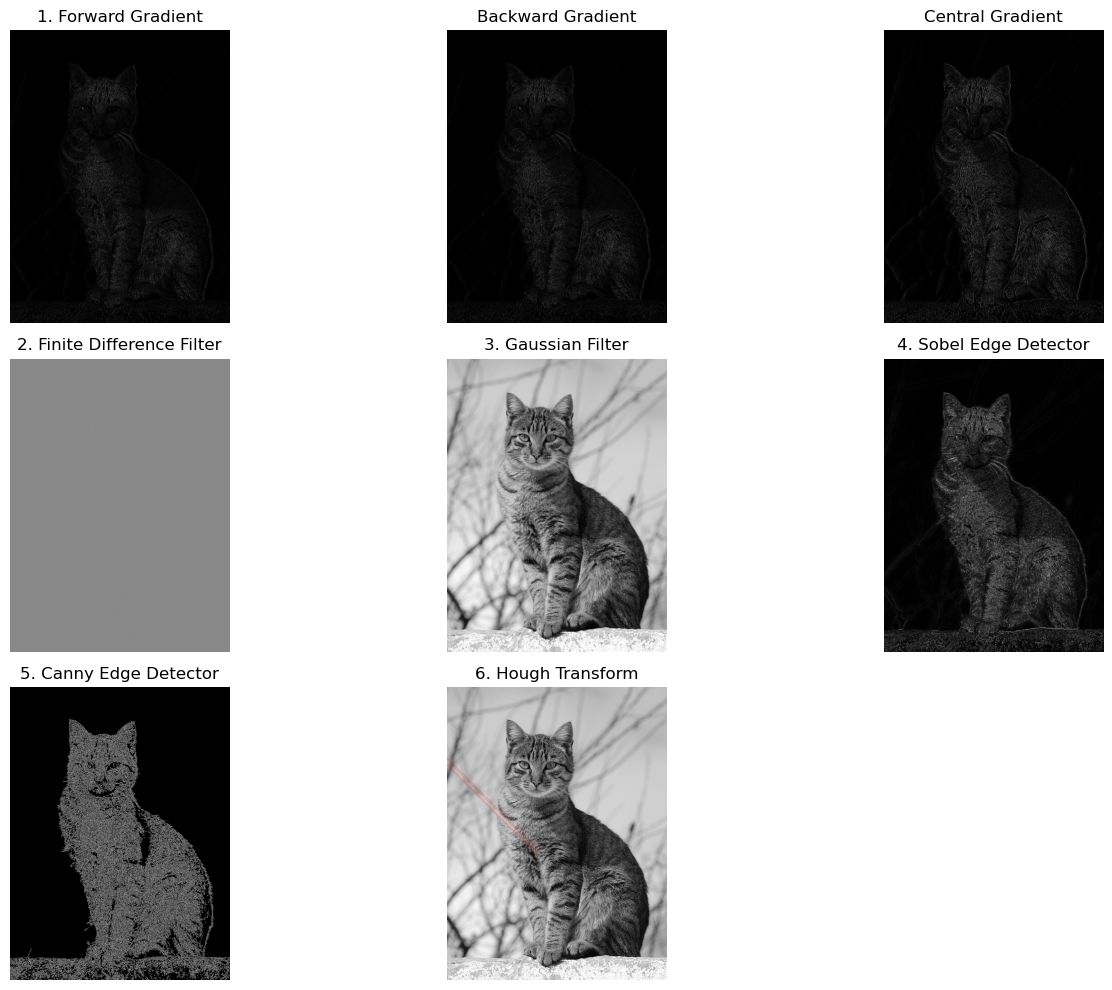

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('cat.jpg', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(14,10))

# 1. Backward, Forward, Central Gradient

# Forward gradient
kernel_forward = np.array([[0, -1, 1]])
grad_forward = cv2.filter2D(img, -1, kernel_forward)

# Backward gradient
kernel_backward = np.array([[-1, 1, 0]])
grad_backward = cv2.filter2D(img, -1, kernel_backward)

# Central gradient
kernel_central = np.array([[-1, 0, 1]])
grad_central = cv2.filter2D(img, -1, kernel_central)

plt.subplot(3,3,1)
plt.imshow(grad_forward, cmap='gray')
plt.title('1. Forward Gradient')
plt.axis('off')

plt.subplot(3,3,2)
plt.imshow(grad_backward, cmap='gray')
plt.title('Backward Gradient')
plt.axis('off')

plt.subplot(3,3,3)
plt.imshow(grad_central, cmap='gray')
plt.title('Central Gradient')
plt.axis('off')


# 2. Finite Difference Filter

finite_diff = cv2.Laplacian(img, cv2.CV_64F)

plt.subplot(3,3,4)
plt.imshow(finite_diff, cmap='gray')
plt.title('2. Finite Difference Filter')
plt.axis('off')


# 3. Gaussian Filter

gaussian = cv2.GaussianBlur(img, (5,5), 0)

plt.subplot(3,3,5)
plt.imshow(gaussian, cmap='gray')
plt.title('3. Gaussian Filter')
plt.axis('off')


# 4. Sobel Edge Detector

sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel = np.sqrt(sobel_x**2 + sobel_y**2)

plt.subplot(3,3,6)
plt.imshow(sobel, cmap='gray')
plt.title('4. Sobel Edge Detector')
plt.axis('off')


# 5. Canny Edge Detector

canny = cv2.Canny(img, 100, 200)

plt.subplot(3,3,7)
plt.imshow(canny, cmap='gray')
plt.title('5. Canny Edge Detector')
plt.axis('off')


# 6. Hough Transform – Detect Lines

edges = cv2.Canny(img, 100, 200)
hough_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
lines = cv2.HoughLines(edges, 1, np.pi/180, 150)

if lines is not None:
    for i in range(min(5, len(lines))):
        rho, theta = lines[i][0]
        a, b = np.cos(theta), np.sin(theta)
        x0, y0 = a*rho, b*rho
        x1, y1 = int(x0 + 1000*(-b)), int(y0 + 1000*(a))
        x2, y2 = int(x0 - 1000*(-b)), int(y0 - 1000*(a))
        cv2.line(hough_img, (x1,y1), (x2,y2), (255,0,0), 1)

plt.subplot(3,3,8)
plt.imshow(hough_img)
plt.title('6. Hough Transform')
plt.axis('off')

plt.tight_layout()
plt.show()
